## Evaluación parcial número 1.


##1.- Carga y exploración inicial

In [103]:
#Cargar el dataset entregado.
import pandas as pd
df= pd.read_csv("Food_Preference(1).csv")
df.head(5)

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


###Análisis exploratorio de datos (EDA)

In [104]:
#Información general del DataFrame (tipos de datos y valores no nulos)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       290 non-null    object 
 1   Participant_ID  290 non-null    object 
 2   Gender          284 non-null    object 
 3   Nationality     290 non-null    object 
 4   Age             288 non-null    float64
 5   Food            290 non-null    object 
 6   Juice           290 non-null    object 
 7   Dessert         290 non-null    object 
dtypes: float64(1), object(7)
memory usage: 18.3+ KB


None

El resultado de df.info() nos muestra que la columna Gender tiene valores nulos, y Age es de tipo float pero podría ser int

### Columnas categoricas y numericas

In [105]:
#Estadística descriptiva para columnas numéricas
display(df.describe())

,Age
count,288.000000
mean,31.625000
std,20.843326
min,-47.000000
25%,24.000000
50%,28.000000
75%,37.000000
max,263.000000


In [106]:
#Estadística descriptiva para columnas categóricas
display(df.describe(include='object'))

,Timestamp,Participant_ID,Gender,Nationality,Food,Juice,Dessert
count,290,290,284,290,290,290,290
unique,285,288,5,28,7,2,3
top,2019/05/10 1:07:43 AM GMT+8,FPS002,Female,Indian,Traditional food,Fresh Juice,Maybe
freq,2,2,165,242,236,257,123


Para las columnas categóricas, podemos ver el número de valores únicos (unique), la categoría más frecuente (top) y su frecuencia (freq).

In [107]:
#Clasificación de variables y recuento de valores únicos para columnas categóricas
for column in df.select_dtypes(include='object').columns:
    print(f"Columna: {column}")
    print(df[column].value_counts())
    print("\n" + "="*30 + "\n")

Columna: Timestamp
Timestamp
2019/05/10 1:07:43 AM GMT+8    2
2019/05/07 2:59:45 PM GMT+8    2
2019/05/07 3:07:36 PM GMT+8    2
2019/05/08 1:16:11 AM GMT+8    2
2019/05/07 4:58:26 PM GMT+8    2
                              ..
2019/05/07 4:54:25 PM GMT+8    1
2019/05/07 4:52:25 PM GMT+8    1
2019/05/07 4:43:58 PM GMT+8    1
2019/05/07 4:43:54 PM GMT+8    1
2019/05/07 4:59:00 PM GMT+8    1
Name: count, Length: 285, dtype: int64


Columna: Participant_ID
Participant_ID
FPS002    2
FPS101    2
FPS196    1
FPS195    1
FPS194    1
         ..
FPS094    1
FPS093    1
FPS092    1
FPS091    1
FPS099    1
Name: count, Length: 288, dtype: int64


Columna: Gender
Gender
Female       165
Male         116
FEMALE         1
MASCULINO      1
Femal          1
Name: count, dtype: int64


Columna: Nationality
Nationality
Indian         242
Malaysian       10
Indonesia        7
Pakistani        3
Maldivian        2
MY               2
Japan            2
Pakistani        2
Maldivian        1
Pakistan       

Observaciones de los recuentos de valores únicos:
- Gender: Hay un valor nulo y algunas entradas como 'female' en minúsculas, se necesita estandarización.
- Nationality: Parece estar bastante limpia, con 'Indian' como predominante.
- Food: Hay varias formas de escribir 'Traditional food' y 'Western food' (con mayúscula inicial o todo en minúsculas, espacios extra).
- Juice: Algunas entradas como 'Fresh Juice', 'Fresh juice', 'fresh Juice' necesitan estandarización.
- Dessert: También tiene variaciones como 'Maybe', 'maybe', 'Yes', 'yes', 'No', 'no'.

In [108]:
#Recargar el dataset para obtener los datos originales
temp_df = pd.read_csv("Food_Preference(1).csv")

## Agrupaciones por temas para analizar visualamente los datos

### distribución de comida por nacionalidad

In [109]:
#Agrupacion por nationality y Food
print("Agrupar por nacionalidad y preferencia de comida:")
tabla_nat_food = temp_df.groupby(['Nationality', 'Food']).size().unstack(fill_value=0)
display(tabla_nat_food)

Agrupar por nacionalidad y preferencia de comida:


Food,,Traditional Food,Traditional food,Western Food,Western food,traditional food,western Food
Nationality,,,,,,,
,0,0,1,0,0,0,0
Algerian,0,0,1,0,0,0,0
Canadian,0,0,0,1,0,0,0
China,0,0,1,0,0,0,0
Indian,0,1,202,37,1,1,0
Indonesain,0,0,0,1,0,0,0
Indonesia,1,0,6,0,0,0,0
Indonesian,0,0,1,0,0,0,0
Indonesian,0,0,1,0,0,0,0


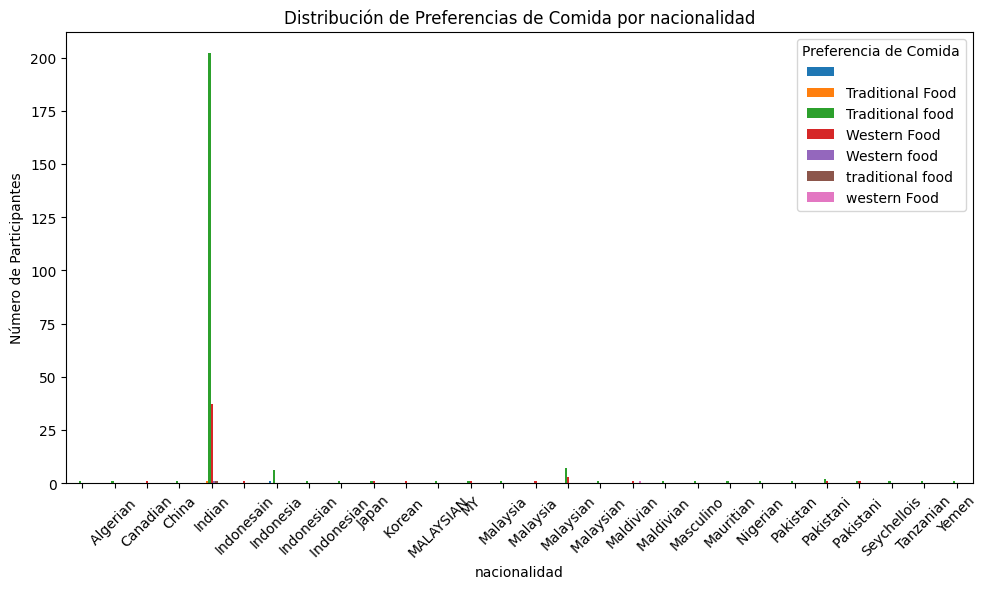

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

tabla_nat_food.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de Preferencias de Comida por nacionalidad')
plt.xlabel('nacionalidad')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Preferencia de Comida')
plt.tight_layout()
plt.show()

### preferencias de postre por tipo de comida que solicita cada usuario

In [111]:
preferencia_food_dessert = df.groupby(['Food', 'Dessert']).size().unstack(fill_value=0)
display(preferencia_food_dessert)

Dessert,Maybe,No,Yes
Food,,,
,1,0,0
Traditional Food,0,0,1
Traditional food,100,49,87
Western Food,19,3,27
Western food,1,0,0
traditional food,1,0,0
western Food,1,0,0


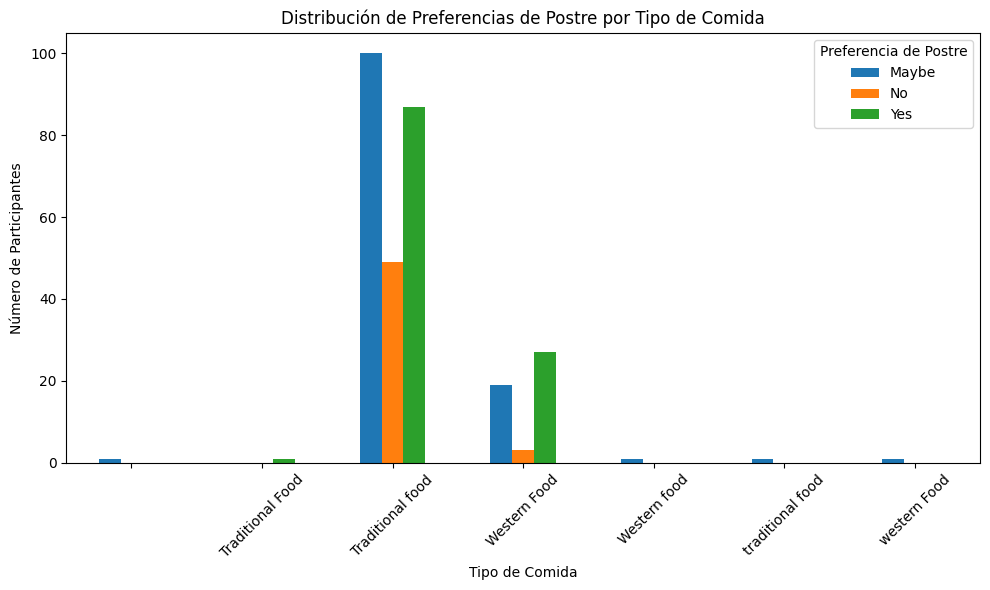

In [112]:
#Tabla prefencia de postre según tipo de comida elegida.
preferencia_food_dessert.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de Preferencias de Postre por Tipo de Comida')
plt.xlabel('Tipo de Comida')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Preferencia de Postre')
plt.tight_layout()
plt.show()

esas son las dos agrupaciones que volveremos a ver más tarde

###Identificación de valores nulos

In [113]:
display(df.isnull().sum())

,0
Timestamp,0
Participant_ID,0
Gender,6
Nationality,0
Age,2
Food,0
Juice,0
Dessert,0


###Detección de Outliers (Valores Atípicos)

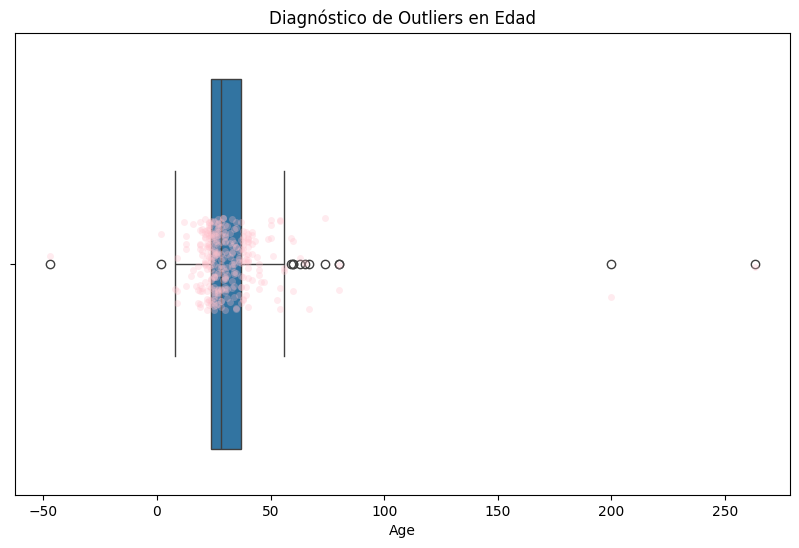

In [114]:
#Deteccion de outliers
plt.figure(figsize=(10, 6))
# Dibujamos el boxplot
sns.boxplot(x=df['Age'])
# Superponemos los puntos reales para ver la densidad del error
sns.stripplot(x=df['Age'], color='pink', alpha=0.3)

plt.title('Diagnóstico de Outliers en Edad')
plt.show()

Podemos ver con los puntitos rosados todos los datos de 'Age'. Y los puntos sin relleno se identifican como outliers.

##2.-Manipulación de datos

### Identificación de Registros Duplicados

In [115]:
# Identificar y mostrar los registros duplicados en el DataFrame original (temp_df)
filas_dupli = temp_df[temp_df.duplicated(keep=False)]
print(f"Registros duplicados en el DataFrame original:\n")
display(filas_dupli)


Registros duplicados en el DataFrame original:



,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
101,2019/05/07 4:58:26 PM GMT+8,FPS101,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe
102,2019/05/07 4:58:26 PM GMT+8,FPS101,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


 Joins, merges y concatenaciones no aplican en nuestro caso pues solo estamos trabajando con un único conjunto de datos. Estas operaciones se utilizan cuando se necesita combinar información de dos o más DataFrames diferentes en uno solo notebook.

##3.-Limpieza

Eliminación de Registros Duplicados. Dos datos en columna 'Participant_ID' duplicados

In [116]:
# Eliminar registros duplicados
df.drop_duplicates(inplace=True)
print(f"Número de registros duplicados después de la eliminación: {df.duplicated().sum()}")

Número de registros duplicados después de la eliminación: 0


### seleccion de columnas relevantes

Seleccionaremos para nuestro caso las columnas: 'Participant_ID', 'Nationality', 'Age', 'Food', 'Juice' y 'Dessert'. Consideramos que tiempo no es relevante para predecir

Eliminaremos las columnas de: 'Timestamp'y 'Gender'

In [117]:
df = df.drop(columns=['Timestamp', 'Gender'], errors='ignore')


print("Primeras 5 filas del DataFrame después de eliminar 'Timestamp' y 'Gender':")
display(df.head())

Primeras 5 filas del DataFrame después de eliminar 'Timestamp' y 'Gender':


,Participant_ID,Nationality,Age,Food,Juice,Dessert
0,FPS001,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,FPS002,Indian,22.0,Western Food,Carbonated drinks,Yes
3,FPS003,Indian,31.0,Western food,Fresh Juice,Maybe
4,FPS004,Indian,25.0,Traditional food,Fresh Juice,Maybe
5,FPS005,Indian,27.0,Traditional food,Fresh Juice,Maybe


Tomamos esta decisión pues se predecirá que Comida prefieren los participantes según su nacionalidad y si van a desear postre según el tipo de comida que eligieron

Necesitamos 'Participant_ID' para saber después a que persona pertenece cada comida.

Y necesitamos 'Age' para lograr el escalamiento de variables numéricas y la transformación de datos.


### Limpieza y estandarización de la columna 'Age'

La columna 'Age' tiene valores nulos y es de tipo flotante. Para limpiarla, rellenamos los valores nulos con la moda y luego la convertimos a tipo entero.

In [118]:
import numpy as np
# Rellenar los valores nulos en 'Age' con la moda
moda_age = df['Age'].mode()[0]
df['Age'] = df['Age'].fillna(moda_age)

# Reemplazar valores de edad menores que 0 o mayores que 110 con la moda
df['Age'] = df['Age'].apply(lambda x: moda_age if x < 0 or x > 110 else x)

# Convertir la columna 'Age' a tipo entero
df['Age'] = df['Age'].astype(int)

print(f"Valores nulos actualizados en 'Age': {df['Age'].isnull().sum()}")
print("Tipo de dato de 'Age' después de la limpieza:")
display(df['Age'].dtype)
print("Primeros valores de 'Age' después de la limpieza:")
display(df['Age'].head())

Valores nulos actualizados en 'Age': 0
Tipo de dato de 'Age' después de la limpieza:


dtype('int64')

Primeros valores de 'Age' después de la limpieza:


,Age
0,24
1,22
3,31
4,25
5,27


### Eliminación de filas con valores vacíos en la columna 'Food'

Se eliminan las filas donde la columna 'Food' contenga filas vacías o solo espacios en blanco.

In [119]:
# Eliminar filas donde 'Food' es una cadena vacía o solo contiene espacios en blanco
df = df[df['Food'].str.strip() != '']
df['Food'] = df['Food'].str.lower()
#Rellenar los nulos con la moda
Food_relle = df['Food'].mode()[0]
df['Food'] = df['Food'].fillna(Food_relle)
print(f"Valores vacíos en la columna 'Food': {df['Food'].isnull().sum()}")
display(df['Food'].value_counts())

Valores vacíos en la columna 'Food': 0


,count
Food,
traditional food,237
western food,50


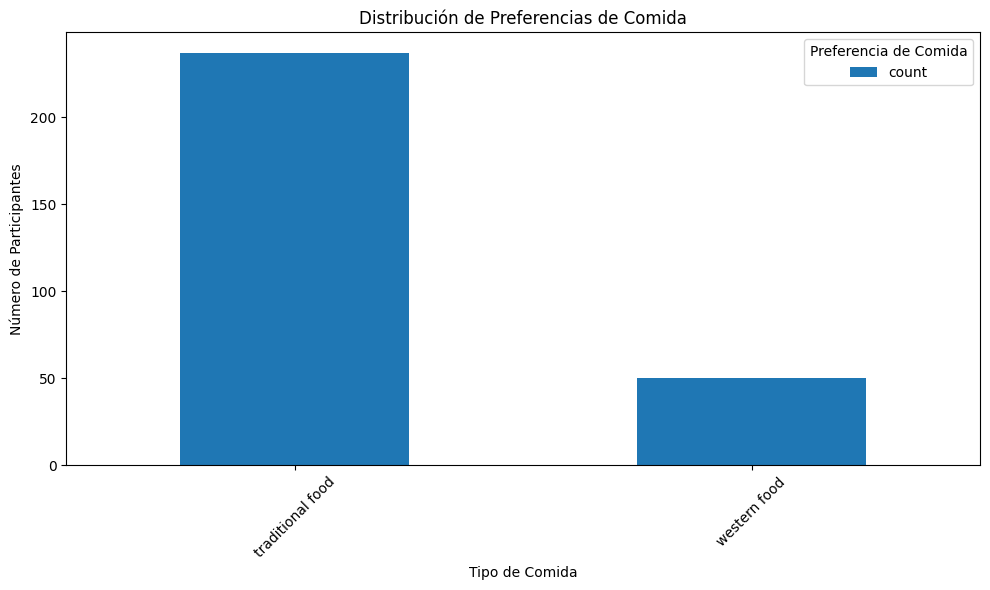

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns


food_cuenta = df['Food'].value_counts()

food_cuenta.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de Preferencias de Comida')
plt.xlabel('Tipo de Comida')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Preferencia de Comida')
plt.tight_layout()
plt.show()

### Estandarización de 'Nationality' reemplazando valores inconsistentes con la moda


In [121]:
#Cortamos espacios en blanco y dejamos las letras en minúsculas
df['Nationality'] = df['Nationality'].str.strip().str.lower()

# Calcular la moda de la columna 'Nationality' después de la limpieza inicial
#[0] se usa porque .mode() puede devolver varios valores si hay múltiples modas
moda_nationality = df['Nationality'].mode()[0]
print(f"La moda de la columna 'Nationality' es: '{moda_nationality}'")

#Definimos un diccionario de mapeo para estandarizar las nacionalidades
nat_estandarizacion = {
    'masculino': moda_nationality,
    'my': moda_nationality,
    'indonesain': 'indonesian',
    'pakistan': 'pakistani',
    'japan': 'japanese',
    'china': 'chinese',
    'yemen': 'yemeni',
    'malaysia': 'malaysian',
    'indonesia': 'indonesian'
}

#Aplicar el mapeo a la columna 'Nationality'
df['Nationality'] = df['Nationality'].replace(nat_estandarizacion)

print("\nValores de 'Nationality' después de aplicar el mapeo con la moda:")
display(df['Nationality'].value_counts())

La moda de la columna 'Nationality' es: 'indian'

Valores de 'Nationality' después de aplicar el mapeo con la moda:


,count
Nationality,
indian,243
malaysian,14
indonesian,9
pakistani,6
maldivian,3
japanese,2
canadian,1
tanzanian,1
nigerian,1


ahora borramos todas las filas vacías

In [122]:
df = df[df['Nationality'].str.strip() != '']

In [123]:
#Clasificación de variables y recuento de valores únicos para columnas categóricas
for column in df.select_dtypes(include=['object', 'category']).columns:
    print(f"Columna: {column}")
    print(df[column].value_counts())
    print("\n" + "="*30 + "\n")

Columna: Participant_ID
Participant_ID
FPS288    1
FPS001    1
FPS002    1
FPS003    1
FPS004    1
         ..
FPS019    1
FPS018    1
FPS017    1
FPS016    1
FPS015    1
Name: count, Length: 286, dtype: int64


Columna: Nationality
Nationality
indian         243
malaysian       14
indonesian       9
pakistani        6
maldivian        3
japanese         2
tanzanian        1
canadian         1
nigerian         1
korean           1
algerian         1
seychellois      1
chinese          1
mauritian        1
yemeni           1
Name: count, dtype: int64


Columna: Food
Food
traditional food    236
western food         50
Name: count, dtype: int64


Columna: Juice
Juice
Fresh Juice          254
Carbonated drinks     32
Name: count, dtype: int64


Columna: Dessert
Dessert
Maybe    121
Yes      113
No        52
Name: count, dtype: int64




### verificamos nulos




In [124]:
display(df.isnull().sum())

,0
Participant_ID,0
Nationality,0
Age,0
Food,0
Juice,0
Dessert,0


##4.- Transformaciones.

### Creación de la Variable 'AgeGroup' (Agrupación por Edad)

Transformamos la columna numérica 'Age' en una columna categórica 'AgeGroup' para representar rangos de edad. Esto puede ayudar a identificar patrones relacionados con grupos generacionales o etapas de vida en la preferencia de alimentos y postres.

In [125]:
import numpy as np
# Definir los límites de los rangos de edad y sus etiquetas
bins = [0, 18, 25, 35, 50, 65, 110]
labels = ['<18', '18-25', '26-35', '36-50', '51-65', '>65']

# Crear la nueva columna 'AgeGroup' utilizando pd.cut
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print("Distribución de la nueva columna 'AgeGroup':")
display(df['AgeGroup'].value_counts())

print("\nPrimeras 5 filas del DataFrame con la nueva columna 'AgeGroup':")
display(df.head())

Distribución de la nueva columna 'AgeGroup':


,count
AgeGroup,
26-35,119
18-25,70
36-50,63
51-65,15
<18,14
>65,5



Primeras 5 filas del DataFrame con la nueva columna 'AgeGroup':


,Participant_ID,Nationality,Age,Food,Juice,Dessert,AgeGroup
0,FPS001,indian,24,traditional food,Fresh Juice,Maybe,18-25
1,FPS002,indian,22,western food,Carbonated drinks,Yes,18-25
3,FPS003,indian,31,western food,Fresh Juice,Maybe,26-35
4,FPS004,indian,25,traditional food,Fresh Juice,Maybe,26-35
5,FPS005,indian,27,traditional food,Fresh Juice,Maybe,26-35


### predicciones

Ahora entramos a la parte donde logramos ver cuanta relacion tienen unas columnas con otras

### Relación entre la nacionalidad del participante y el tipo de comida que prefiere.

In [126]:
#Agrupacion por nationality y Food
print("Agrupar por nacionalidad y preferencia de comida:")
tabla_nafo_limpia = df.groupby(['Nationality', 'Food'], observed=False).size().unstack(fill_value=0)
display(tabla_nafo_limpia)

Agrupar por nacionalidad y preferencia de comida:


Food,traditional food,western food
Nationality,,
algerian,1,0
canadian,0,1
chinese,1,0
indian,205,38
indonesian,8,1
japanese,1,1
korean,0,1
malaysian,10,4
maldivian,1,2


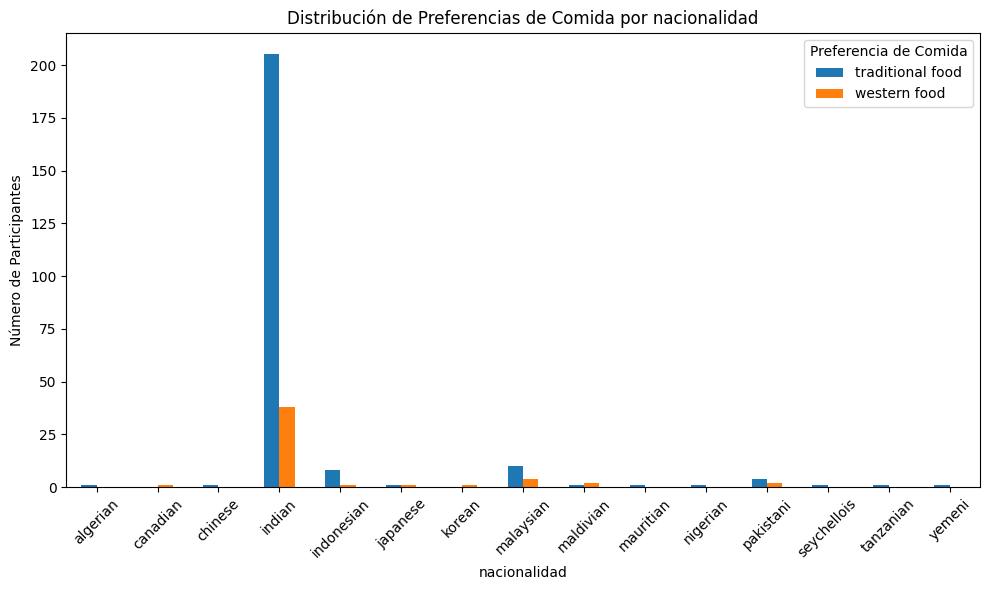

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

tabla_nafo_limpia.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de Preferencias de Comida por nacionalidad')
plt.xlabel('nacionalidad')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Preferencia de Comida')
plt.tight_layout()
plt.show()

In [130]:
# Calcular la probabilidad de elegir cada tipo de comida dado la nacionalidad
prob_nafo = tabla_nafo_limpia.apply(lambda x: x / x.sum(), axis=1)
print("Probabilidad de preferencia de comida por nacionalidad:")
display(prob_nafo)

Probabilidad de preferencia de comida por nacionalidad:


Food,traditional food,western food
Nationality,,
algerian,1.000000,0.000000
canadian,0.000000,1.000000
chinese,1.000000,0.000000
indian,0.843621,0.156379
indonesian,0.888889,0.111111
japanese,0.500000,0.500000
korean,0.000000,1.000000
malaysian,0.714286,0.285714
maldivian,0.333333,0.666667


La tabla prob_nafo muestra la probabilidad de que una persona elija un tipo de comida dependiendo de su nacionalidad. Las columnas muestran la proporción de personas de esa nacionalidad que prefieren cada tipo de comida.

Por ejemplo:
Hay un 0.840816 en la columna 'traditional food' para 'indian', esto significa que aproximadamente el 84% de los participantes indios prefieren la comida tradicional.
y el restante prefiere 'Western food'

Resumiendo, logramos mostrar esta tabla que permite cuantificar la fuerza de la relación entre la nacionalidad del participante y la elección del tipo de comida, basándose en la proporción de cada preferencia dentro de cada grupo.

### Relacion entre si desean postre según la preferencia en el tipo de comida y del rango de edad del participante.

In [131]:
preferencia_fodeage_limpia = df.groupby(['Food', 'AgeGroup', 'Dessert'], observed=False).size().unstack(level='Dessert', fill_value=0)
display(preferencia_fodeage_limpia)

Dessert                    Maybe  No  Yes
Food             AgeGroup                
traditional food <18           2   3    1
                 18-25        24   3   24
                 26-35        45  17   38
                 36-50        26  18   15
                 51-65         3   6    6
                 >65           0   2    3
western food     <18           4   0    4
                 18-25         6   0   13
                 26-35        10   2    7
                 36-50         1   1    2
                 51-65         0   0    0
                 >65           0   0    0

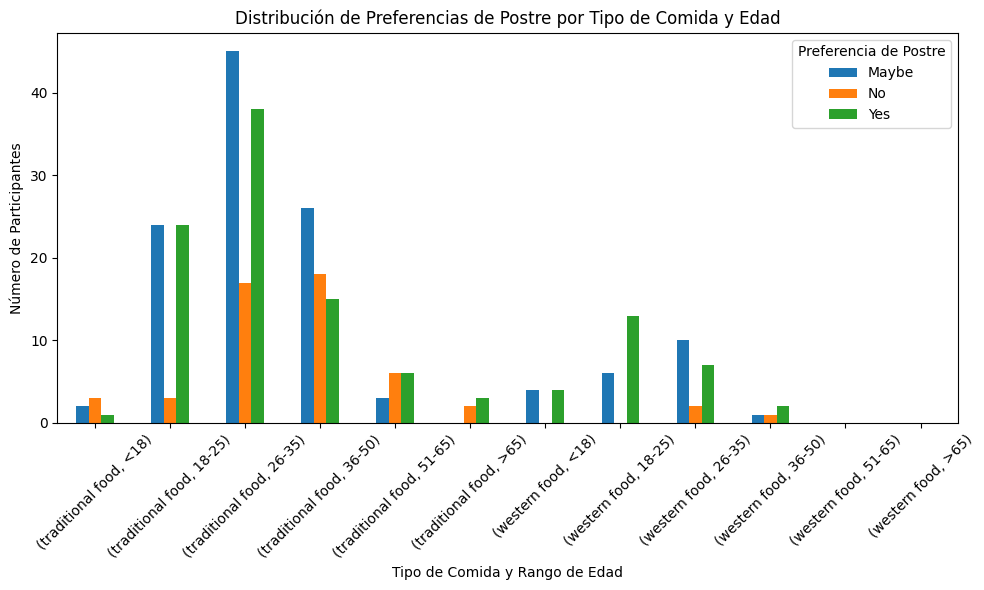

In [134]:
#Manera visual de entender los datos recientemente calculados
preferencia_fodeage_limpia.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de Preferencias de Postre por Tipo de Comida y Edad')
plt.xlabel('Tipo de Comida y Rango de Edad')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Preferencia de Postre')
plt.tight_layout()
plt.show()

In [135]:
#Calcular la probabilidad de elegir cada tipo de postre dado el tipo de comida y el rango de edad.
prob_fode_limpia = preferencia_fodeage_limpia.apply(lambda x: x / x.sum(), axis=1)
print("Probabilidad de preferencia de postre por tipo de comida y rango de edad:")
display(prob_fode_limpia)

Probabilidad de preferencia de postre por tipo de comida y rango de edad:


Dessert                       Maybe        No       Yes
Food             AgeGroup                              
traditional food <18       0.333333  0.500000  0.166667
                 18-25     0.470588  0.058824  0.470588
                 26-35     0.450000  0.170000  0.380000
                 36-50     0.440678  0.305085  0.254237
                 51-65     0.200000  0.400000  0.400000
                 >65       0.000000  0.400000  0.600000
western food     <18       0.500000  0.000000  0.500000
                 18-25     0.315789  0.000000  0.684211
                 26-35     0.526316  0.105263  0.368421
                 36-50     0.250000  0.250000  0.500000
                 51-65          NaN       NaN       NaN
                 >65            NaN       NaN       NaN

Aquí mostramos la probabilidad de elegir un tipo de postre según la preferencia de comida y el rango de edad:

Por ejemplo, en la comida tradicional, los participantes del grupo '26-35' muestran una probabilidad de 'Maybe' (0.44) ligeramente más alta que 'Yes' (0.37) para el postre, mientras que los más jóvenes, en '18-25', tienen probabilidades iguales de 'Maybe' y 'Yes' (0.47).

Y los participantes en el rango '>65' que eligen comida tradicional tienen la mayor probabilidad de decir 'Yes' al postre (0.60).

Para la comida occidental, se observa una tendencia general a una mayor probabilidad de decir 'Yes' al postre, especialmente en el grupo '18-25' con un 0.68, y también para los menores de 18 con un 0.50.


## Preprocesamiento con Pipelines para Machine Learning

Vamos a definir un Pipeline para automatizar los pasos de preprocesamiento, que incluyen:
-   Codificación de variables categóricas: Utilizaremos One-Hot Encoding para las columnas 'Nationality', 'Food' y 'Juice'.
-   Escalado de variables numéricas: Aplicaremos StandardScaler a la columna 'Age'.

También separaremos la variable objetivo 'Dessert' de las características para la preparación del modelo.

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Separar características (X) y variable objetivo (y)
X = df[['Nationality', 'Age', 'Food', 'Juice']]
y = df['Dessert']

#Codificar la variable objetivo 'Dessert' a valores numéricos
label_encoder = LabelEncoder()
y_enco = label_encoder.fit_transform(y)

print("\nPrimeras 5 filas de las características (X):")
display(X.head())
print("\nPrimeras 5 filas de la variable objetivo codificada:")
display(pd.Series(y_enco).head())

#Identificar columnas numéricas y categóricas
numer = ['Age']
categor= ['Nationality', 'Food', 'Juice']

#Crear los preprocesadores
#Preprocesador para características numéricas (escalado)
transfor_numerico= StandardScaler()

#Preprocesador para características categóricas (One-Hot Encoding)
transfor_categ= OneHotEncoder(handle_unknown='ignore')

#Combinar los preprocesadores usando ColumnTransformer
prepro= ColumnTransformer(
    transformers=[
        ('num', transfor_numerico, numer),
        ('cat', transfor_categ, categor)
    ])

print("\nPreprocesador ColumnTransformer creado.")

#Crear un Pipeline de preprocesamiento
preprocessing_pipeline = Pipeline(steps=[('preprocessor', prepro)])

print("\nPipeline de preprocesamiento creado.")

#Demostrar el uso del pipeline (ajustar y transformar los datos)
X_procesado = preprocessing_pipeline.fit_transform(X)

print("\nDimensiones de X antes del procesamiento:", X.shape)
print("Dimensiones de X después del procesamiento:", X_procesado.shape)
print("\nPrimeras 5 filas de los datos preprocesados:")
display(pd.DataFrame(X_procesado).head())


Primeras 5 filas de las características (X):


,Nationality,Age,Food,Juice
0,indian,24,traditional food,Fresh Juice
1,indian,22,western food,Carbonated drinks
3,indian,31,western food,Fresh Juice
4,indian,25,traditional food,Fresh Juice
5,indian,27,traditional food,Fresh Juice



Primeras 5 filas de la variable objetivo codificada:


,0
0,0
1,2
2,0
3,0
4,0



Preprocesador ColumnTransformer creado.

Pipeline de preprocesamiento creado.

Dimensiones de X antes del procesamiento: (286, 4)
Dimensiones de X después del procesamiento: (286, 20)

Primeras 5 filas de los datos preprocesados:


,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...


In [138]:
df.to_csv('Food_Preference_limpio.csv', index=False)
print('DataFrame guardado exitosamente como Food_Preference_limpio.csv')

DataFrame guardado exitosamente como Food_Preference_limpio.csv


### Comparación de Nacionalidad: antes y después de la Limpieza

Este gráfico visualiza el efecto de la limpieza y estandarización de la columna 'Nationality'. Se compara la distribución de nacionalidades en el DataFrame original 'temp_df' y en el DataFrame limpio 'df'.

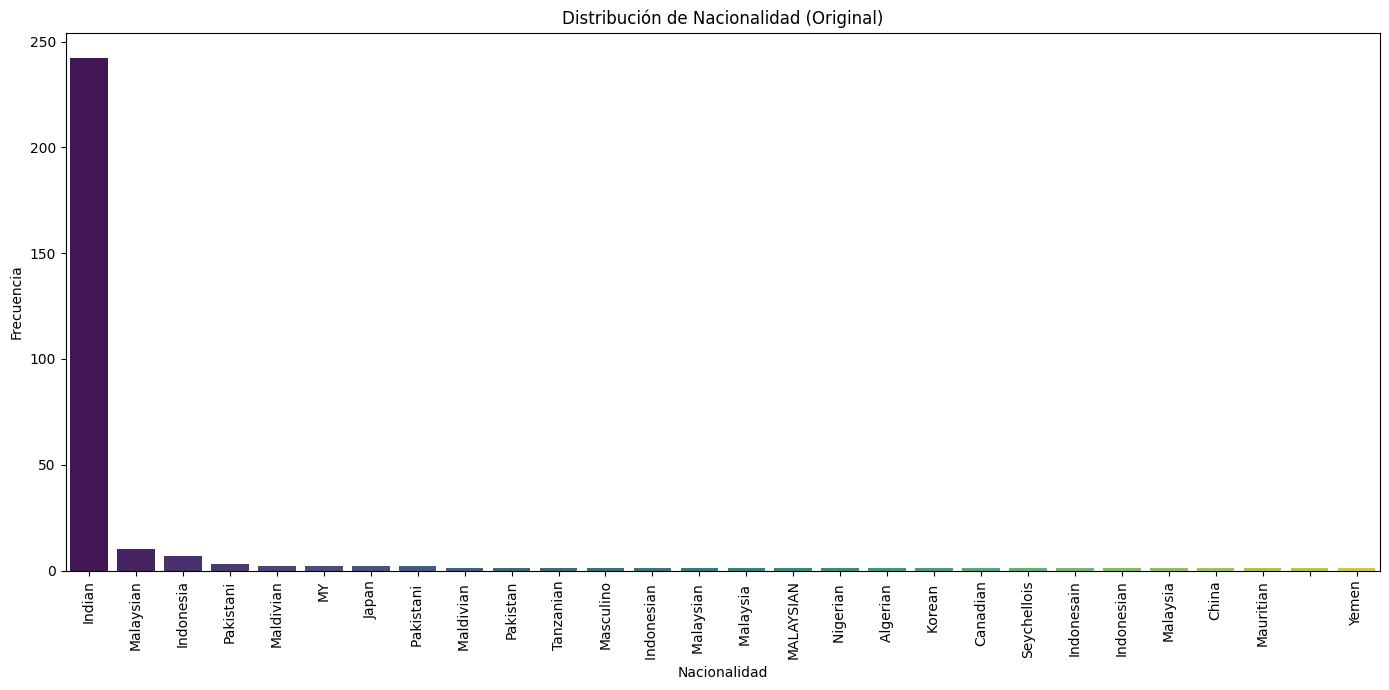

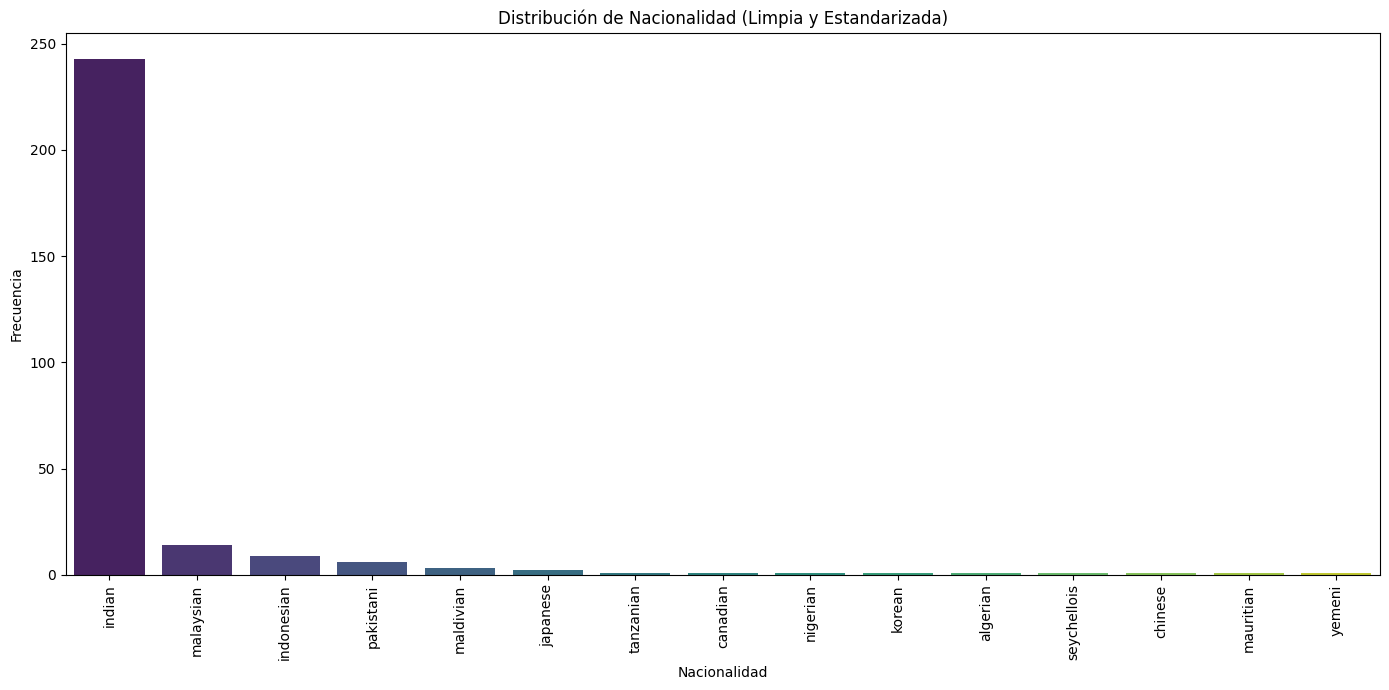

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

#Gráfico de Nacionalidad (Original)

#Obtener los recuentos de la columna 'Nationality' en el DataFrame original
nationality_original = temp_df['Nationality'].value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=nationality_original.index, y=nationality_original.values, palette='viridis', hue=nationality_original_counts.index, legend=False)
plt.title('Distribución de Nacionalidad (Original)')
plt.xlabel('Nacionalidad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#Gráfico de Nacionalidad (Limpia y Estandarizada)

#Obtener los recuentos de la columna 'Nationality' en el DataFrame limpio
nationality_limpio = df['Nationality'].value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=nationality_limpio.index, y=nationality_limpio.values, palette='viridis', hue=nationality_cleaned_counts.index, legend=False)
plt.title('Distribución de Nacionalidad (Limpia y Estandarizada)')
plt.xlabel('Nacionalidad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Comparación de Edad


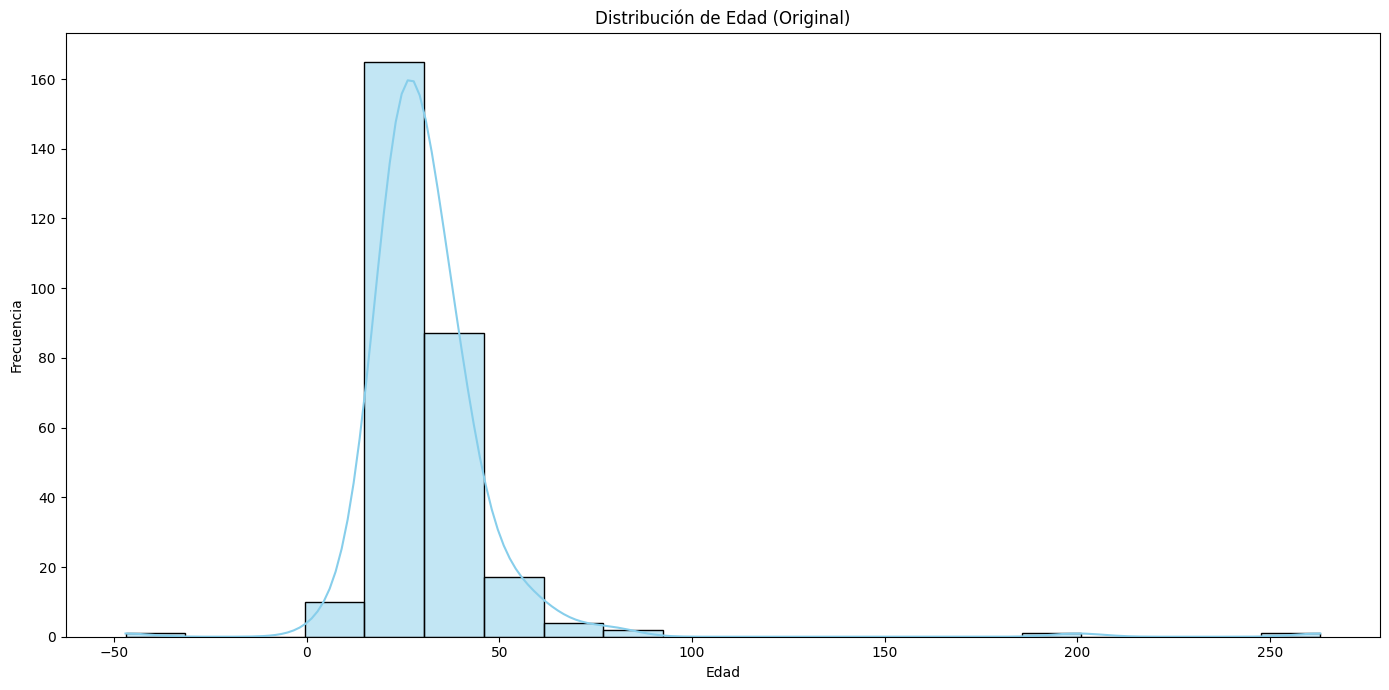

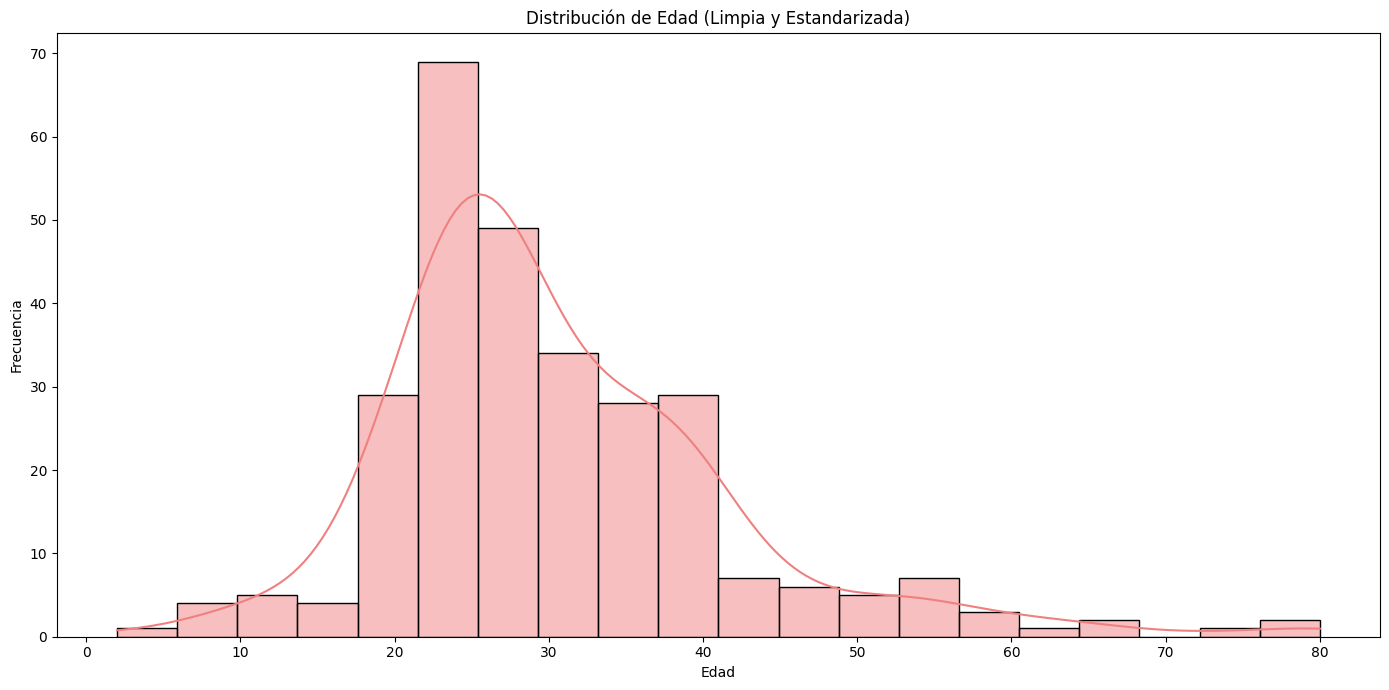

In [140]:
#Gráfico de Edad (Original)

plt.figure(figsize=(14, 7))
sns.histplot(temp_df['Age'].dropna(), kde=True, bins=20, color='skyblue')
plt.title('Distribución de Edad (Original)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#Gráfico de Edad (Limpia y Estandarizada)

plt.figure(figsize=(14, 7))
sns.histplot(df['Age'], kde=True, bins=20, color='lightcoral')
plt.title('Distribución de Edad (Limpia y Estandarizada)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Comparación de Preferencia de Comida


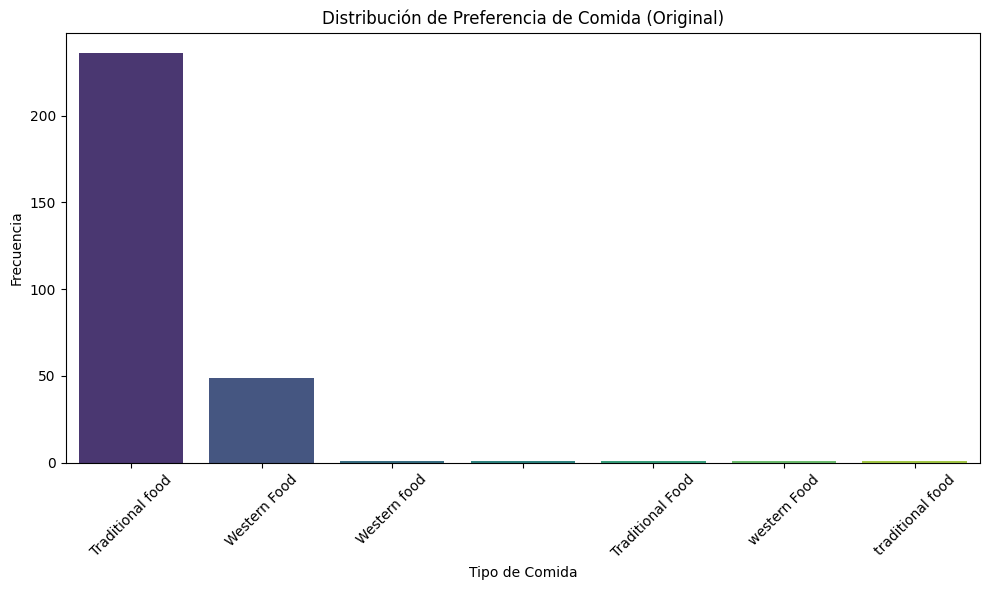

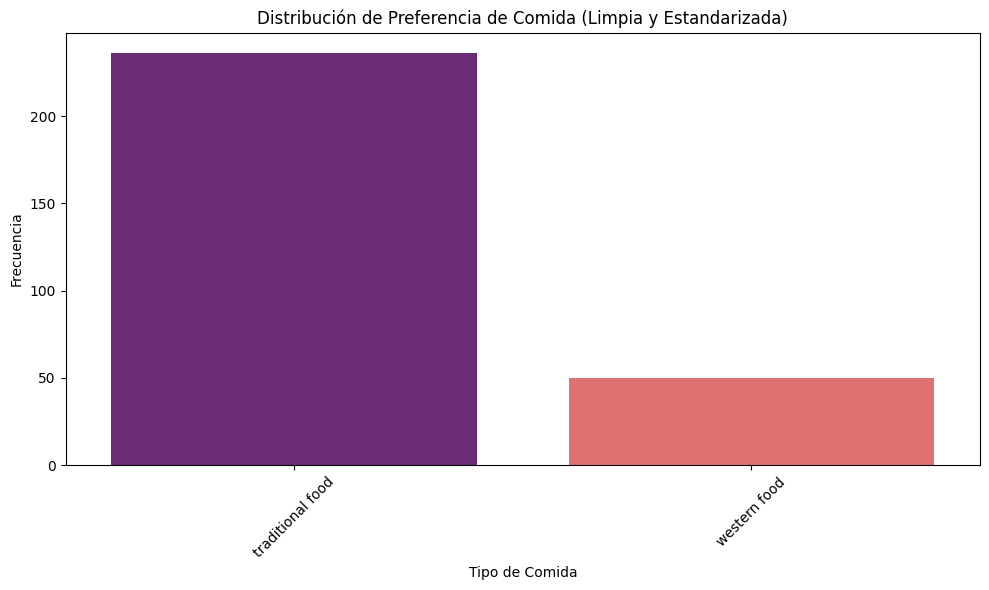

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

#Gráfico de Preferencia de Comida (Original)

#Obtener los recuentos de la columna 'Food' en el DataFrame original
food_original= temp_df['Food'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=food_original.index, y=food_original.values, palette='viridis', hue=food_original.index, legend=False)
plt.title('Distribución de Preferencia de Comida (Original)')
plt.xlabel('Tipo de Comida')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Gráfico de Preferencia de Comida (Limpia y Estandarizada)

#Obtener los recuentos de la columna 'Food' en el DataFrame limpio
food_limpio= df['Food'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=food_limpio.index, y=food_limpio.values, palette='magma', hue=food_limpio.index, legend=False)
plt.title('Distribución de Preferencia de Comida (Limpia y Estandarizada)')
plt.xlabel('Tipo de Comida')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()